In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA #e un fel de compresor de date ;el imi monitorizeaza sistemul in cazul intretinerii predictive ;selecteaza cei mai importanti parametrii din cei 16 grupand cumva in 3 parti
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

from sklearn.ensemble import IsolationForest
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings('ignore')


In [31]:
print("Incarcarea datelor si analiza initiala\n") #Incarcarea datelor +alte comenzi (lab 2)

df = pd.read_csv(r"C:\SBC2\Proiect_SBC_tema2\data.csv")

# curatare nume coloane (problema reala din dataset)
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace('\xa0', ' ') #curăță numele coloanelor, rezolvă probleme reale din dataset (spații ascunse)

print(df.head())
print("\nDimensiunea dataset-ului este:", df.shape)   #imi arata cate linii si coloane am in data set 
df.info()

print("\nColoanele disponibile:\n", df.columns.tolist())


Incarcarea datelor si analiza initiala

   index  Lever position  Ship speed (v)  \
0      0           1.138               3   
1      1           2.088               6   
2      2           3.144               9   
3      3           4.161              12   
4      4           5.140              15   

   Gas Turbine (GT) shaft torque (GTT) [kN m]  \
0                                     289.964   
1                                    6960.180   
2                                    8379.229   
3                                   14724.395   
4                                   21636.432   

   GT rate of revolutions (GTn) [rpm]  \
0                            1349.489   
1                            1376.166   
2                            1386.757   
3                            1547.465   
4                            1924.313   

   Gas Generator rate of revolutions (GGn) [rpm]  \
0                                       6677.380   
1                                       6828.469 

In [32]:
def functie1_analiza(df):
      #Cu aceasta linie de cod verific datele lipsa folosind tot o camnda din labul 2 

    print("\nVerificam daca exista date lipsa:\n", df.isnull().sum())  #verifica valori nule , si face suma elementelor lipsa
    print("\nDescriere statistica:\n", df.describe())  #Aceasta comanda oferă numărul de valori, media, deviația standard, valoarea minimă și quartilele pentru fiecare coloană numerică,explicatie luata din labul 2
    print("\nValori unice:\n", df.nunique()) #comanda lab 2 
    print("\nTipuri de date:\n", df.dtypes) #tipul fiecarei coloane

    return df

df = functie1_analiza(df)



Verificam daca exista date lipsa:
 index                                                     0
Lever position                                            0
Ship speed (v)                                            0
Gas Turbine (GT) shaft torque (GTT) [kN m]                0
GT rate of revolutions (GTn) [rpm]                        0
Gas Generator rate of revolutions (GGn) [rpm]             0
Starboard Propeller Torque (Ts) [kN]                      0
Port Propeller Torque (Tp) [kN]                           0
Hight Pressure (HP) Turbine exit temperature (T48) [C]    0
GT Compressor inlet air temperature (T1) [C]              0
GT Compressor outlet air temperature (T2) [C]             0
HP Turbine exit pressure (P48) [bar]                      0
GT Compressor inlet air pressure (P1) [bar]               0
GT Compressor outlet air pressure (P2) [bar]              0
GT exhaust gas pressure (Pexh) [bar]                      0
Turbine Injecton Control (TIC) [%]                        0
Fuel

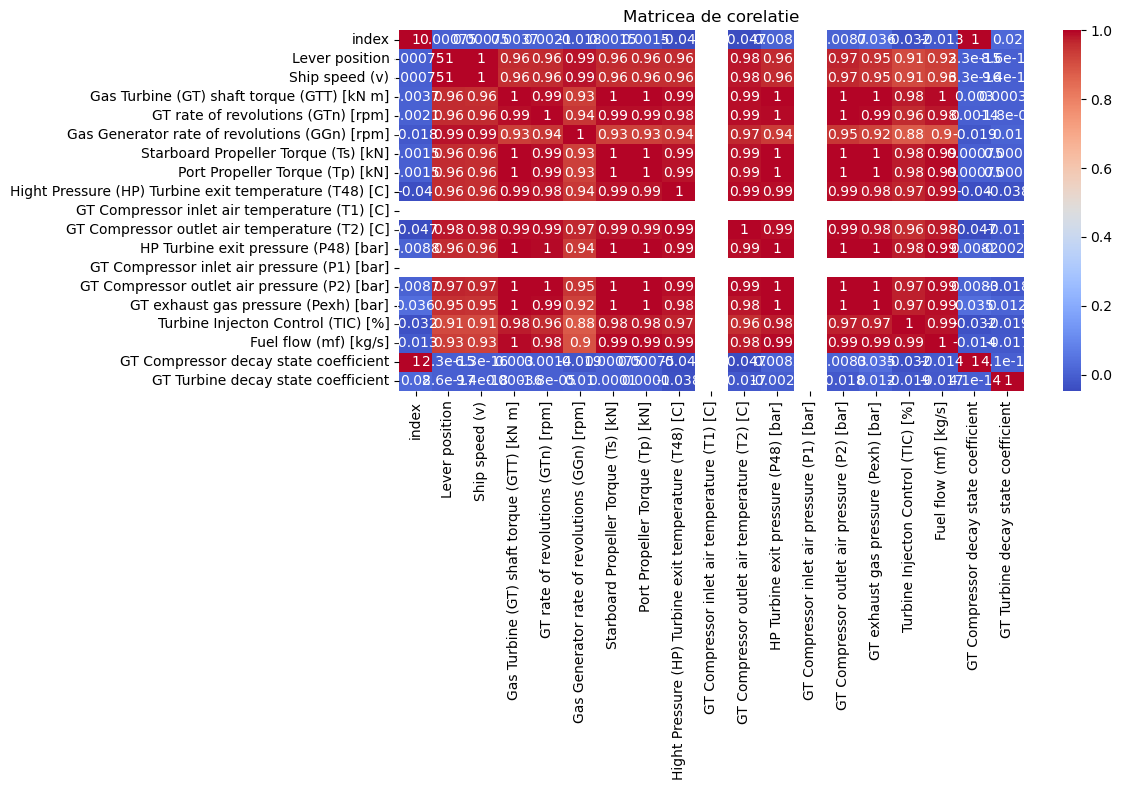

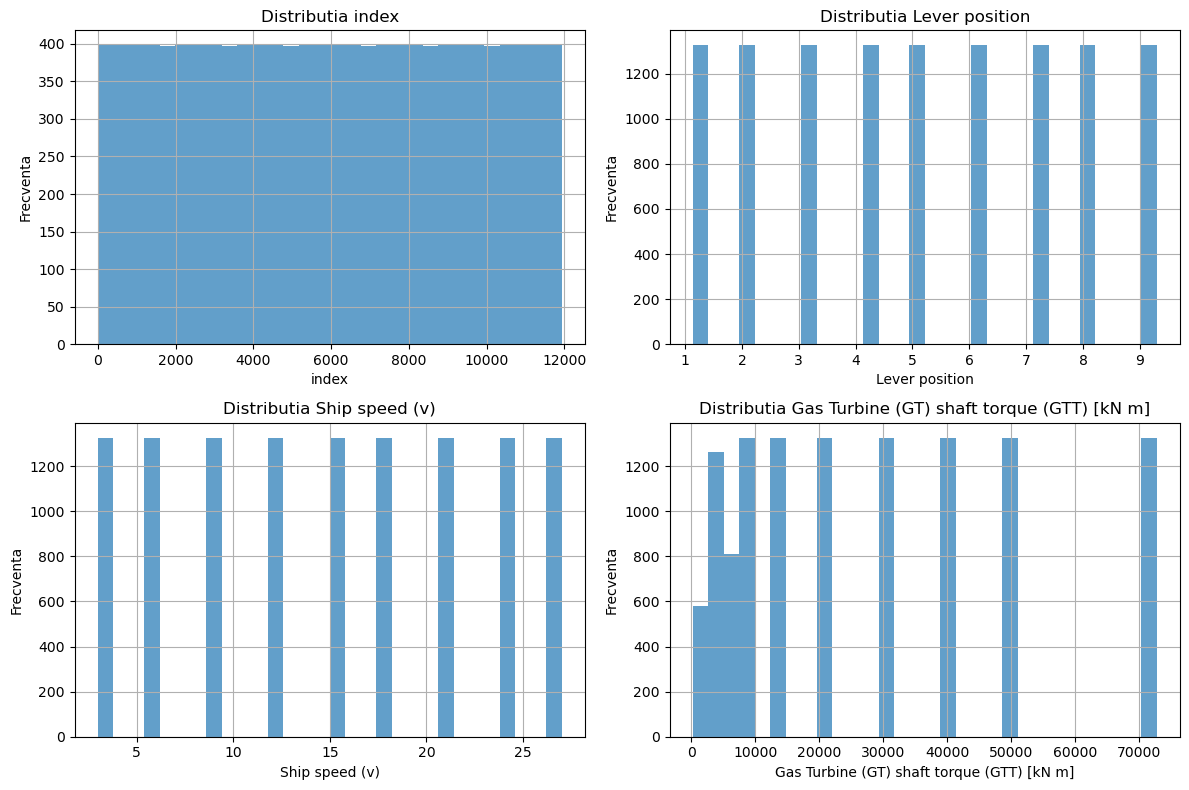

True

In [33]:
#Partea asta se refera la formarea unei vizualizari de baza 
def functie2_vizualizareBaza(df):
 #incep prin a scrie matricea de corelatie din labul 5 slide 11
    plt.figure(figsize=(12, 8))
    corr = df.corr() #calculează corelația Pearson între coloane numerice
    sns.heatmap(corr, annot=True, cmap="coolwarm") #afișează matricea de corelație colorată
    plt.title("Matricea de corelatie")
    plt.tight_layout()
    plt.show()
 #creez un "tablou" cu 4 casute pentru grafice (2 randuri , 2 coloane ),12 lugime, 8 latime (unitati)
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    num_cols = df.select_dtypes(include=[np.number]).columns[:4]  #aleg primii 4 parametrii numerici din dataset

    for i, col in enumerate(num_cols):
        ax = axes[i // 2, i % 2] #// impartire fara rest(cate grupe complete am ) si % (cati parametrii am)
         #denenez histograma
        df[col].hist(bins=30, ax=ax, alpha=0.7) #este desenata histograma pentru param curent 
        ax.set_title(f"Distributia {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Frecventa")

    plt.tight_layout()
    plt.show()

    return True

functie2_vizualizareBaza(df)


Corelatii puternice (|r| > 0.7):
  + Starboard Propeller Torque (Ts) [kN] ↔ Port Propeller Torque (Tp) [kN]: 1.000
  + Lever position ↔ Ship speed (v): 1.000
  + index ↔ GT Compressor decay state coefficient: 1.000
  + HP Turbine exit pressure (P48) [bar] ↔ GT Compressor outlet air pressure (P2) [bar]: 0.999
  + Gas Turbine (GT) shaft torque (GTT) [kN m] ↔ Starboard Propeller Torque (Ts) [kN]: 0.999
  + Gas Turbine (GT) shaft torque (GTT) [kN m] ↔ Port Propeller Torque (Tp) [kN]: 0.999
  + Gas Turbine (GT) shaft torque (GTT) [kN m] ↔ HP Turbine exit pressure (P48) [bar]: 0.999
  + Starboard Propeller Torque (Ts) [kN] ↔ HP Turbine exit pressure (P48) [bar]: 0.998
  + Port Propeller Torque (Tp) [kN] ↔ HP Turbine exit pressure (P48) [bar]: 0.998
  + HP Turbine exit pressure (P48) [bar] ↔ GT exhaust gas pressure (Pexh) [bar]: 0.998

Corelatii moderate (0.5 < |r| ≤ 0.7): 0


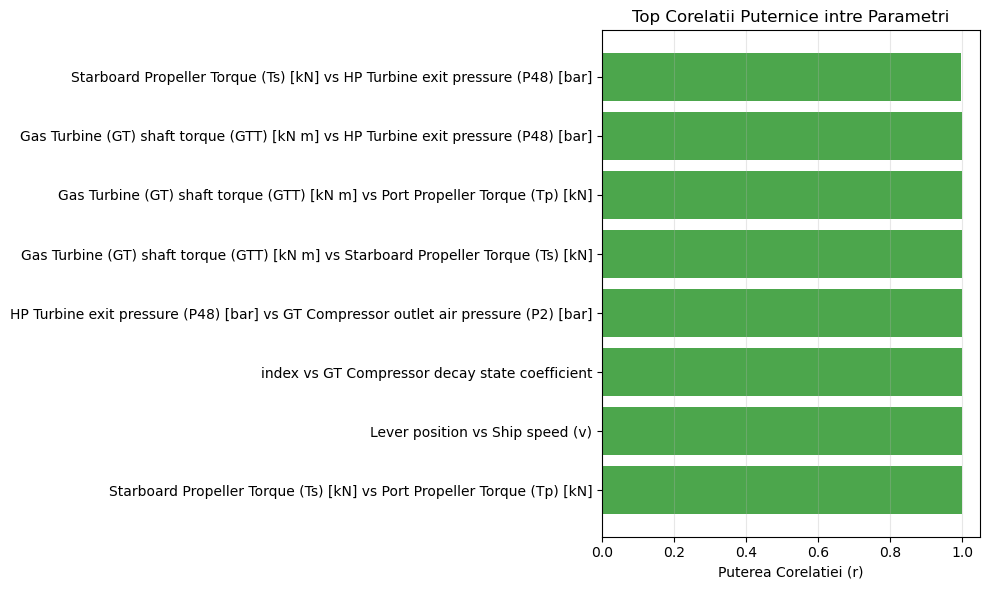

In [34]:
#Partea a5-a se refera la o analiza mai avansata a corelatiei

def functie3_corelatieAvansata(df):
    corr_matrix=df.corr() #calculez corelatia dintre coloana i si coloana j
    strong_correlations = []
    moderate_correlations = [] # liste pentruu cele 2 tipuri de corelatii

    # Iteram prin toate perechile de coloane
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):# se incepe cu i+1 ca sa nu am perechi repetate
            feature1 = corr_matrix.columns[i]
            feature2 = corr_matrix.columns[j]
            corr_value = corr_matrix.iloc[i, j] #legatura dintre cele 2 feature-uri(valoarea corelatiei)

            #Verificare de corelatii puternice
            if abs(corr_value) > 0.7:
                strong_correlations.append({'feature1': feature1, 'feature2': feature2, 'correlation': corr_value})
            # Verifivare de corelatii moderate
            elif 0.5 < abs(corr_value) <= 0.7:
                moderate_correlations.append({'feature1': feature1, 'feature2': feature2, 'correlation': corr_value})

    strong_correlations.sort(key=lambda x: abs(x['correlation']), reverse=True) #sortează corelațiile puternice descrescător după valoarea absolută.

    # Afisare
    print("Corelatii puternice (|r| > 0.7):")
    for c in strong_correlations[:10]:  # primele 10
        semn = "+" if c['correlation'] > 0 else "-" #afisez daca corelatia este cu - sau cu +(pozitiva sau negativa )
        print(f"  {semn} {c['feature1']} ↔ {c['feature2']}: {c['correlation']:.3f}")

    print(f"\nCorelatii moderate (0.5 < |r| ≤ 0.7): {len(moderate_correlations)}")

    # Vizualizare top corelatii puternice
    if strong_correlations:
        top_corrs = strong_correlations[:8]
        features = [f"{c['feature1']} vs {c['feature2']}" for c in top_corrs]#numele coloanelor
        values = [c['correlation'] for c in top_corrs] #numele corelatiilor
        colors = ['green' if v > 0 else 'red' for v in values]# verde =>pozitiva , rosu=>negativa

        plt.figure(figsize=(10,6))
        plt.barh(features, values, color=colors, alpha=0.7) #grafic cu cele mai puternice corelații
        plt.xlabel('Puterea Corelatiei (r)')
        plt.title('Top Corelatii Puternice intre Parametri')
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()

    return strong_correlations, moderate_correlations

# Apel functie
strong_corrs, moderate_corrs = functie3_corelatieAvansata(df)              


Varianta explicata PCA:
Componenta 1: 0.803 (0.803)
Componenta 2: 0.118 (0.921)
Componenta 3: 0.059 (0.980)


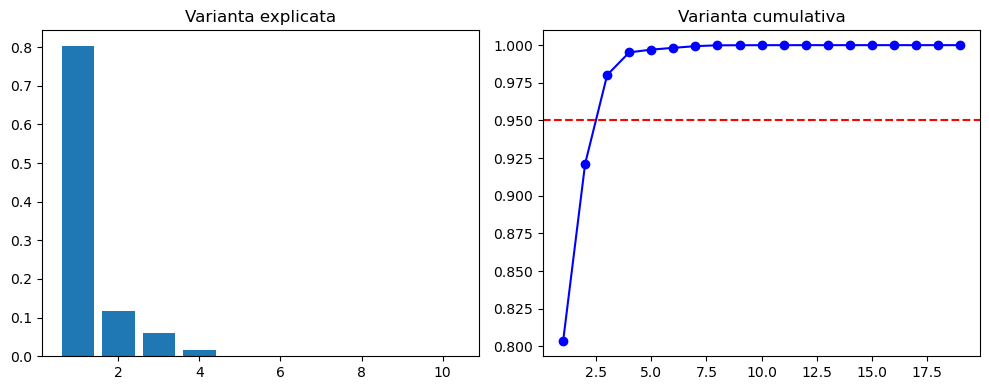

In [20]:
#Partea  a5-a se bazeaza pe reducerea dimensionalitatii si PCA(compresor inteligent de date)
def functie4_reduceDimensiune(df):

    num_cols = df.select_dtypes(include=[np.number]).columns  #selectez doar coloanele numerice
    x = df[num_cols].fillna(df[num_cols].mean()) #cu aceasta linie de cod vreau sa extrag doae valorile numerice si sa completez valorile lipsa  cu media fiecarei coloane  

     #standardizare datelor=>este necesara pentru PCA pentru ,deoarece aceasta este sensibila la scara variabilelor
    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(x) #lab 5 slide 12 de la "scale the data"

    pca = PCA() #aplica pca
    x_pca = pca.fit_transform(x_scaled) #laborator 4 slide 13

     #calculez varianta explicita
    var_exp = pca.explained_variance_ratio #Este un atribut al obiectului PCA din scikit-learn. Reprezintă proporția din varianța totală a datelor explicată de fiecare componentă principală.
     #cu cumsum() calcukez suma cumulativa a elementelor
    var_cum = var_exp.cumsum()

    print("\nVarianta explicata PCA:")
    for i, (e, c) in enumerate(zip(var_exp, var_cum)): #exp → varianța explicată de componenta curentă ,cum → varianța totală explicată până la acea componentă
        print(f"Componenta {i+1}: {e:.3f} ({c:.3f})") #zip pune in perechi cele 2 variante 
        if c >= 0.95:
            break

    n = min(10, len(var_exp))

    #Acum voi face un plot pentru varainta

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.bar(range(1, n+1), var_exp[:n])
    plt.title("Varianta explicata")

    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(var_cum)+1), var_cum, 'bo-')
    plt.axhline(0.95, color='r', linestyle='--')
    plt.title("Varianta cumulativa")

    plt.tight_layout()
    plt.show()

    return pca, x_pca, scaler

pca, x_pca, scaler_pca = functie4_reduceDimensiune(df)


In [21]:
def functie5_features(df):

    df_copy = df.copy() #fac o copie a data frame-ului
    num_cols = df.select_dtypes(include=[np.number]).columns #Feature de degradare si trend 

    for col in num_cols:
        df_copy[f"{col}_change"] = df[col].diff().fillna(0)  #calculez diferența între valoarea curentă și valoarea precedentă pentru fiecare rând
        #medii mobile pentru detectie
        df_copy[f"{col}_rolling_mean_5"] = df[col].rolling(5, min_periods=1).mean() #calculez media ultimelor 5 valori pentru fiecare rând.
        df_copy[f"{col}_rolling_std_5"] = df[col].rolling(5, min_periods=1).std().fillna(0)#calculez volatilitatea valorilor din ultimele 5 rânduri

     #Feature de eficienta operationala
    if 'Ship speed (v)' in df.columns and 'Gas Turbine (GT) shaft torque (GTT) [kN m]' in df.columns:
        df_copy['operational_efficency'] = (
            df['Ship speed (v)'] /
            (df['Gas Turbine (GT) shaft torque (GTT) [kN m]'] + 1e-6)# eficienta operationala
        )

    print("Feature-uri initiale:", len(df.columns))
    print("Feature-uri dupa inginerie:", len(df_copy.columns))
    print(f"Feature-urile noi create sunt:{len(df_copy.columns)-len(df.columns)}")
    

    return df_copy

df_inginerie = functie5_features(df)


Feature-uri initiale: 19
Feature-uri dupa inginerie: 77
Feature-urile noi create sunt:58


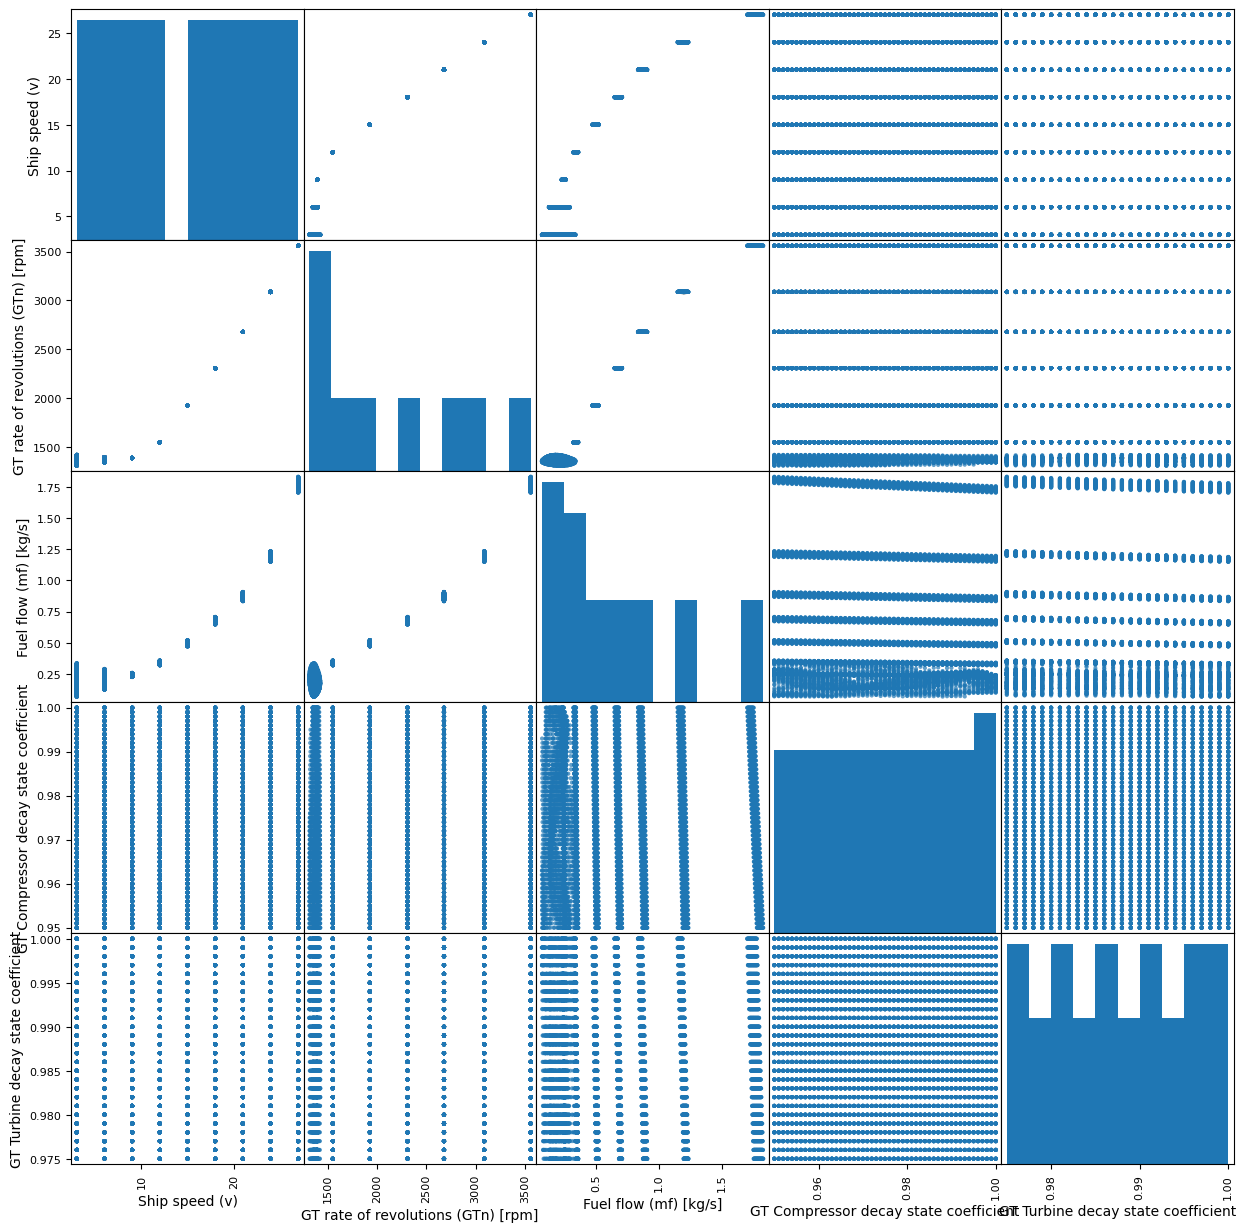

In [22]:
def functie7_analizaAvansata(df):

    parametriiCheie = [
        'Ship speed (v)',
        'GT rate of revolutions (GTn) [rpm]',
        'Fuel flow (mf) [kg/s]',
        'GT Compressor decay state coefficient',
        'GT Turbine decay state coefficient'
    ]

    param_exist = [p for p in parametriiCheie if p in df.columns]

    if len(param_exist) >= 2:
        pd.plotting.scatter_matrix(df[param_exist], figsize=(15, 15), alpha=0.7)
        plt.show()

functie7_analizaAvansata(df)


Shape X: (11934, 75)
Shape y_comp: (11934,)
Shape y_turb: (11934,)

=== MODEL: Random Forest ===
Compresor → RMSE=0.0000 | R²=1.0000
Turbina →  RMSE=0.0000 | R²=1.0000

=== MODEL: Gradient Boosting ===
Compresor → RMSE=0.0001 | R²=1.0000
Turbina →  RMSE=0.0000 | R²=1.0000

=== MODEL: SVR ===
Compresor → RMSE=0.0147 | R²=-0.0003
Turbina →  RMSE=0.0075 | R²=-0.0003

   REZULTATE COMPARATIVE
                   Compresor_RMSE  Compresor_R2  Turbina_RMSE  Turbina_R2
Random Forest            0.000045      0.999990  2.129684e-15    1.000000
Gradient Boosting        0.000056      0.999985  3.156237e-05    0.999983
SVR                      0.014664     -0.000285  7.549717e-03   -0.000255

>> Cel mai bun model pentru compresor este: Random Forest


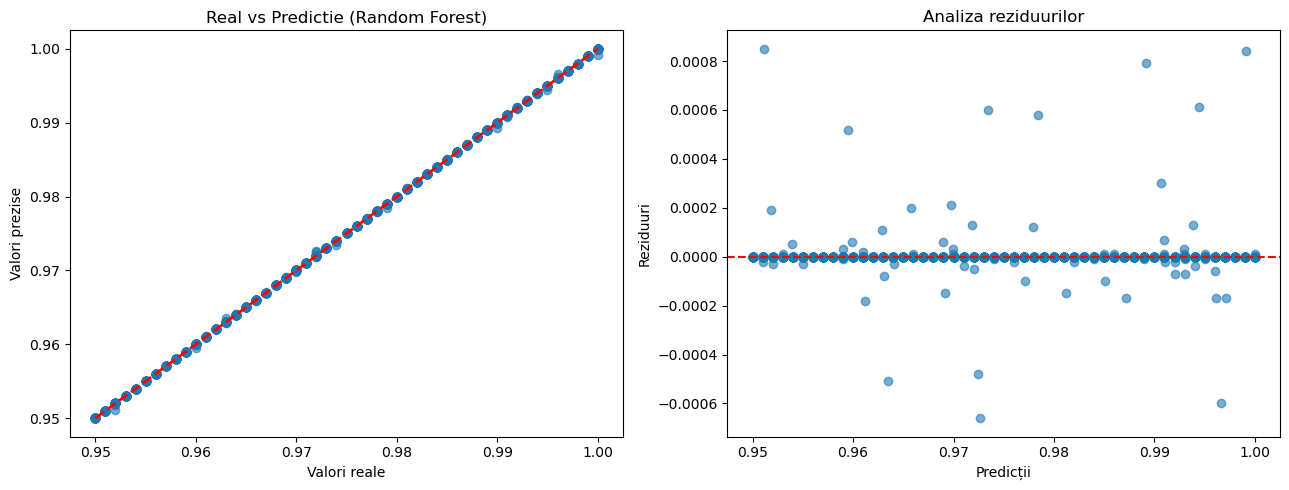

In [25]:
df_inginerie.columns = df_inginerie.columns.str.strip() #separă input-ul de ținte

#partea a 9-a
def functie8_modelarePredictiva(df_inginerie):

    col_comp = 'GT Compressor decay state coefficient'
    col_turb = 'GT Turbine decay state coefficient'

    tinte = [col_comp, col_turb]

    # Verificare existență coloane
    if not all(c in df_inginerie.columns for c in tinte):
        print("Eroare: coloanele țintă nu există în dataframe!")
        return None, None, None


    X = df_inginerie.drop(columns=tinte, errors='ignore')
    X = X.select_dtypes(include=[np.number])

   
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='median')
    X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

   
    y_comp = df_inginerie[col_comp]
    y_turb = df_inginerie[col_turb]

    print(f"Shape X: {X.shape}")
    print(f"Shape y_comp: {y_comp.shape}")
    print(f"Shape y_turb: {y_turb.shape}")

 
    X_train_c, X_test_c, yc_train, yc_test = train_test_split(X, y_comp, test_size=0.2, random_state=42)
    X_train_t, X_test_t, yt_train, yt_test = train_test_split(X, y_turb, test_size=0.2, random_state=42)

   
    scaler_c = StandardScaler()
    scaler_t = StandardScaler()

    X_train_scaled_c = scaler_c.fit_transform(X_train_c)
    X_test_scaled_c = scaler_c.transform(X_test_c)

    X_train_scaled_t = scaler_t.fit_transform(X_train_t)
    X_test_scaled_t = scaler_t.transform(X_test_t)

 
    models = {
        'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=300, random_state=42),
        'SVR': SVR(kernel='rbf')
    }

    results = {}

   
    for name, model in models.items():
        print(f"\n=== MODEL: {name} ===")

        # -------- COMPRESOR --------
        if name == "SVR":
            model.fit(X_train_scaled_c, yc_train)
            yc_pred = model.predict(X_test_scaled_c)
        else:
            model.fit(X_train_c, yc_train)
            yc_pred = model.predict(X_test_c)

        rmse_c = np.sqrt(mean_squared_error(yc_test, yc_pred))
        r2_c = r2_score(yc_test, yc_pred)

        # -------- TURBINĂ --------
        model_t = type(model)()   # clonăm modelul corect

        if name == "SVR":
            model_t.fit(X_train_scaled_t, yt_train)
            yt_pred = model_t.predict(X_test_scaled_t)
        else:
            model_t.fit(X_train_t, yt_train)
            yt_pred = model_t.predict(X_test_t)

        rmse_t = np.sqrt(mean_squared_error(yt_test, yt_pred))
        r2_t = r2_score(yt_test, yt_pred)

        # Salvăm rezultatele
        results[name] = {
            "Compresor_RMSE": rmse_c,
            "Compresor_R2": r2_c,
            "Turbina_RMSE": rmse_t,
            "Turbina_R2": r2_t
        }

        print(f"Compresor → RMSE={rmse_c:.4f} | R²={r2_c:.4f}")
        print(f"Turbina →  RMSE={rmse_t:.4f} | R²={r2_t:.4f}")

    # ==== CONVERSIE LA DATAFRAME ====
    results_df = pd.DataFrame(results).T

    print("\n============================")
    print("   REZULTATE COMPARATIVE")
    print("============================")
    print(results_df)

    # ==== GRAFIC PENTRU CEL MAI BUN MODEL ====
    best_model_name = results_df["Compresor_R2"].idxmax()
    print(f"\n>> Cel mai bun model pentru compresor este: {best_model_name}")

    if best_model_name == "SVR":
        best_model = SVR(kernel='rbf')
        best_model.fit(X_train_scaled_c, yc_train)
        yc_best_pred = best_model.predict(X_test_scaled_c)
    else:
        best_model = type(models[best_model_name])()
        best_model.fit(X_train_c, yc_train)
        yc_best_pred = best_model.predict(X_test_c)

   
    plt.figure(figsize=(13, 5))

    plt.subplot(1, 2, 1)
    plt.scatter(yc_test, yc_best_pred, alpha=0.6)
    plt.plot([yc_test.min(), yc_test.max()],
             [yc_test.min(), yc_test.max()], 'r--', lw=2)
    plt.xlabel("Valori reale")
    plt.ylabel("Valori prezise")
    plt.title(f"Real vs Predictie ({best_model_name})")

    plt.subplot(1, 2, 2)
    reziduuri = yc_test - yc_best_pred
    plt.scatter(yc_best_pred, reziduuri, alpha=0.6)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel("Predicții")
    plt.ylabel("Reziduuri")
    plt.title("Analiza reziduurilor")

    plt.tight_layout()
    plt.show()

    return results_df, models, scaler_c
rezultate_modele, modele_antrenate, scaler_model = functie8_modelarePredictiva(df_inginerie)

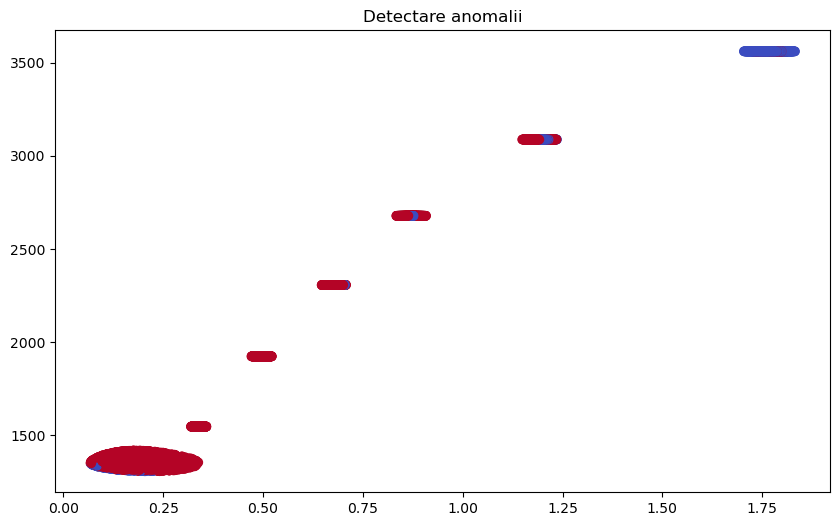

In [23]:
def functie10_detectare_anomalii(df):

    features = [
        'Fuel flow (mf) [kg/s]',
        'GT rate of revolutions (GTn) [rpm]'
    ]

    X = df[features].fillna(method='ffill')

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    iso = IsolationForest(contamination=0.05, random_state=42) #presupune că 5% din date sunt anormale

    df = df.copy()
    df['anomalie_detectata'] = iso.fit_predict(X_scaled) #marchează fiecare punct: normal / anomalie

    plt.figure(figsize=(10, 6))
    plt.scatter(df[features[0]], df[features[1]], c=df['anomalie_detectata'], cmap='coolwarm')
    plt.title("Detectare anomalii")
    plt.show()

    return df

df = functie10_detectare_anomalii(df)


In [24]:
def generare_raport_final():

    print("=" * 80)
    print("RAPORT FINAL – SISTEM NAVAL")
    print("=" * 80)
    print("• Analiza exploratorie realizata")
    print("• PCA aplicat cu succes")
    print("• Feature engineering implementat")
    print("• Modele ML antrenate")
    print("• Anomalii detectate")
    print("• Sistem potrivit pentru mentenanta predictiva")

generare_raport_final()


RAPORT FINAL – SISTEM NAVAL
• Analiza exploratorie realizata
• PCA aplicat cu succes
• Feature engineering implementat
• Modele ML antrenate
• Anomalii detectate
• Sistem potrivit pentru mentenanta predictiva
